In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.constants as pc
import astropy.units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy.table import vstack
from scipy.stats import ttest_rel


def red_chi_squared(y_values, y_uncertainties, model_data, dof):

  chi_squared = np.sum(((model_data - y_values) / y_uncertainties)**2)
  
  red_chi_sq = chi_squared / (len(y_values) - dof)

  return red_chi_sq


In [10]:
def filter_best_bh_mass(table):
    """
    Filter the input table to select the best black hole mass based on BIC comparison.

    Parameters
    ----------
    table : astropy.table.Table
        Input table containing columns for conv_BIC, gauss_BIC, bh_mass_conv, and bh_mass_gauss.

    Returns
    -------
    filtered_table : astropy.table.Table
        Table with additional columns for best black hole mass, its uncertainty, and the model used.
    """
    conv_bic = np.asarray(table["conv_BIC"], dtype=float)
    gauss_bic = np.asarray(table["gauss_BIC"], dtype=float)
    conv_mass = np.asarray(table["bh_mass_conv"], dtype=float)
    conv_mass_err = np.asarray(table["bh_mass_conv_err"], dtype=float)
    gauss_mass = np.asarray(table["bh_mass_gauss"], dtype=float)
    gauss_mass_err = np.asarray(table["bh_mass_gauss_err"], dtype=float)

    use_conv = np.full(conv_bic.shape, False, dtype=bool)
    mask_both = ~np.isnan(conv_bic) & ~np.isnan(gauss_bic)
    use_conv[mask_both] = conv_bic[mask_both] < (gauss_bic[mask_both] - 8)
    use_conv[np.isnan(gauss_bic) & ~np.isnan(conv_bic)] = True

    best_mass = np.where(use_conv, conv_mass, gauss_mass)
    best_mass_err = np.where(use_conv, conv_mass_err, gauss_mass_err)
    best_model = np.where(use_conv, "conv", "gauss")

    table["bh_mass_best"] = best_mass
    table["bh_mass_best_err"] = best_mass_err
    table["bh_mass_best_model"] = best_model

    return table

In [11]:
def open_shay_table(file_path):
        # Open the FITS file
        with fits.open(file_path) as hdul:
            # Show the HDU structure
            hdul.info()

            # Usually the table is in extension 1
            data = hdul[1].data

        # Convert to an Astropy Table
        tbl = Table(data)
        #print("Number of objects = ", len(tbl))

        # Print column names
        print("\nColumns:")
        print(tbl.colnames)

        """
        tbl.write("Ha_mass_BIC_BAGPIPES_DJA.csv",
          format="ascii.csv",
          overwrite=True)

        print("\nSaved table to Ha_mass_BIC_BAGPIPES_DJA.csv")
        """


        return tbl


Ha_BAGPIPES_table = open_shay_table("/nvme/scratch/work/alberttg/Summer_project/Ha_mass_BIC_BAGPIPES_DJA_err")
NII_BAGPIPES_table = open_shay_table("/nvme/scratch/work/alberttg/Summer_project/NII_mass_BIC_BAGPIPES_DJA_err")
# Contains all of Shay's photometry outputs from BAGPIPES runs of Halpha data
# I haven't used anything from this table yet

Ha_table = open_shay_table("/nvme/scratch/work/alberttg/Summer_project/Ha_mass_BIC_DJA_err")
# All Shay's data from Ha line fitting
Ha_table = filter_best_bh_mass(Ha_table)
# Shay's Ha line fitting table with the best black hole mass selected based on BIC comparison



fields = [
    "ra",
    "dec",
    "redshift_2",
    "bh_mass_best_model",
    "bh_mass_best",
    "bh_mass_best_err"
]

HA_DJA_TABLE = Ha_table[fields]
# Data from fitting Halpha with different models

"""
Ha_RA = Ha_table["ra"]
Ha_DEC = Ha_table["dec"]
Ha_bh_mass_conv = Ha_table["bh_mass_conv"]
#Ha_bh_mass_conv_err = Ha_table["bh_mass_conv_err"]
Ha_conv_BIC = Ha_table["conv_BIC"]
Ha_bh_mass_gauss = Ha_table["bh_mass_gauss"]
#Ha_bh_mass_gauss_err = Ha_table["bh_mass_gauss_err"]
Ha_gauss_BIC = Ha_table["gauss_BIC"]
"""





NII_table = open_shay_table("/nvme/scratch/work/alberttg/Summer_project/NII_mass_BIC_DJA_err")
NII_table = filter_best_bh_mass(NII_table)

NII_DJA_TABLE = NII_table[fields]
# My data from Shay's fitting of Halpha and NII lines


Filename: /nvme/scratch/work/alberttg/Summer_project/Ha_mass_BIC_BAGPIPES_DJA_err
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1  Joined        1 BinTableHDU    484   37R x 233C   [18A, 21A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, K, D, D, K, D, D, 55A, K, K, 55A, K, D, D, 5A, D, D, D, D, D, D, D, D, 10A, 60A, 30A, 20A, 30A, J, E, 21A, 15A, 55A, J, J, 59A, K, D, D, 5A, 6A, D, K, 30A, 29A, K, K, K, K, 24A, K, K, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K, D, D, D, D, D, D, 21A, D, 18A, 18A, 18A, 19A, 18A, 18A, 18A, 17A, 18A, 22A, 20A, 20A, 29A, 29A, 29A, 25A, 25A, 25A, 21A, 21A, 21A, 18A, 18A, 55A, 18A, 18A, 18A, 18A, 18A, 18A, 18A, 18A, 18A, 18A, 18A, 18A


Columns:
['bh_mass_gauss_err', 'gauss_amplitude16', 'gauss_amplitude50', 'gauss_amplitude84', 'gauss_sigma16', 'gauss_sigma50', 'gauss_sigma84', 'gauss_centre16', 'gauss_centre50', 'gauss_centre84', 'gauss_base16', 'gauss_base50', 'gauss_base84', 'gauss_narrow_line_amplitude16', 'gauss_narrow_line_amplitude50', 'gauss_narrow_line_amplitude84', 'gauss_narrow_line_sigma16', 'gauss_narrow_line_sigma50', 'gauss_narrow_line_sigma84', 'gauss_nii_amplitude16', 'gauss_nii_amplitude50', 'gauss_nii_amplitude84', 'redshift_1', 'bh_mass_gauss', 'file_1', 'z', 'amplitude16', 'amplitude50', 'amplitude84', 'sigma16', 'sigma50', 'sigma84', 'lambda16', 'lambda50', 'lambda84', 'centre16', 'centre50', 'centre84', 'base16', 'base50', 'base84', 'narrow_line_amplitude16', 'narrow_line_amplitude50', 'narrow_line_amplitude84', 'narrow_line_sigma16', 'narrow_line_sigma50', 'narrow_line_sigma84', 'nii_amplitude16', 'nii_amplitude50', 'nii_amplitude84', 'redshift_2', 'name', 'bh_mass_conv', 'conv_BIC', 'gauss_B

Median dz/(1+z): -1.862739436785003e-05
Scatter dz/(1+z): 0.00012181360498282548
p value =  0.04585328546262132


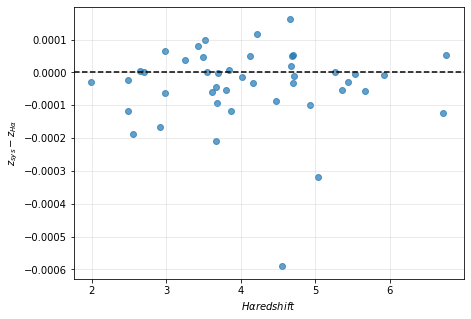

Median dz/(1+z): -3.0837828358146944e-05
Scatter dz/(1+z): 7.666929422014479e-17
p value =  7.993610832145658e-96


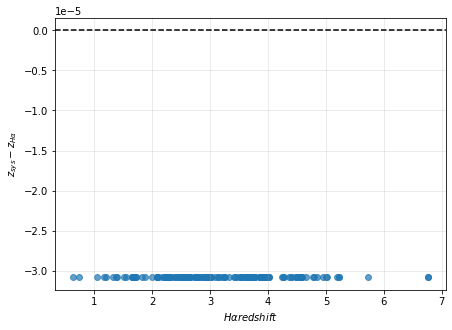

In [12]:
def check_redshifts(tbl):

    if "z" in tbl.colnames and "redshift_2" in tbl.colnames:
            z_vals = np.asarray(tbl["z"], dtype=float)
            redshift_vals = np.asarray(tbl["redshift_2"], dtype=float)
            
            dz = z_vals - redshift_vals
            dz_norm = (z_vals - redshift_vals)/(1 + redshift_vals)

            print("Median dz/(1+z):", np.median(dz_norm))
            print("Scatter dz/(1+z):", np.std(dz_norm))

            t, p = ttest_rel(z_vals, redshift_vals)
            print("p value = ",p)         

            plt.figure(figsize=(7,5))
            plt.scatter(redshift_vals, dz_norm, alpha=0.7)
            plt.axhline(0, color='k', ls='--')
            plt.xlabel(r"${H\alpha} redshift$")
            plt.ylabel(r"$z_{sys} - z_{H\alpha}$")
            plt.grid(alpha=0.3)
            plt.show()
            
    return

check_redshifts(Ha_table)

check_redshifts(NII_table)

In [13]:
def open_catalogue_data(path):
  """
  Reads in a catalogue of data from a FITS file and returns the data as an Astropy Table.
  """

  hdul = fits.open(path)
  hdu_names = [hdu.name for hdu in hdul]

  # sex_cat = [hdu for hdu, name in zip(hdul, hdu_names) if name == "OBJECTS"][0]
    
  # EPOCHS series (Conselice+24, Adams+24, Austin+25, Harvey+25)

  sex_tab = Table.read(path, hdu = "OBJECTS")
  sex_tab_colnames = sex_tab.colnames
  print(sex_tab_colnames)
  # sky position (Ra = ALPHA_J2000, Dec = DELTA_J2000)
  # flux columns: FLUX_APER_{band}_aper_corr_Jy [Jy]
  # flux error columns: FLUXERR_APER_{band}_loc_depth_5pc_Jy [Jy]

  
  eazy_tab = Table.read(path, hdu = "EAZY_SFHZ_BLUE_AGN")
  eazy_tab_colnames = eazy_tab.colnames

  # ID = "IDENT" same as "NUMBER" from sex
  # redshift, z = 'zbest_sfhz_blue_agn_zfree' not median!
  # redshift_errors = ['zbest_16_sfhz_blue_agn_zfree', 'zbest_84_sfhz_blue_agn_zfree']
  # redshift - redshift errors[0] = lower sigma
  # redshift - redshift errors[1] = upper sigma


  eazy_properties_tab = Table.read(path, hdu = 'PROPERTIES_EAZY_SFHZ_BLUE_AGN')
  eazy_properties_tab_colnames = eazy_properties_tab.colnames

  # beta/Muv

  selection_tab = Table.read(path, hdu = "SELECTION")
  selection_tab_colnames = selection_tab.colnames

  # EPOCHS_good_EAZY_sfhz_blue_agn_0.32as == True

  bagpipes_tab = Table.read(path, hdu = 'BAGPIPES_SFH_CONT_BURSTY_ZEAZYSFHZBLUEAGN_3.0,10.0MYR_CALZETTI_LOG_10_Z_LOG_10_BPASS_ZGAUSS_3.0SIG')
  bagpipes_tab_colnames = bagpipes_tab.colnames

  # only run on EPOCHS_good_EAZY_sfhz_blue_agn_0.32as == True AND z > 6.5
  # galaxy properties
  
  return sex_tab, eazy_tab, eazy_properties_tab, selection_tab, bagpipes_tab

In [ ]:
def match_galaxies_by_coord(
    sex_tab, eazy_tab, DJA_table,
    filters
):
    """
    Match a list of RA/Dec coordinates to a catalogue and extract
    selected information.

    Parameters
    ----------
    sex_tab : astropy.table.Table
        Catalogue table.

    DJA_table : astropy.table.Table
        My shortened version of Shay's line fitting table of galaxies to match.

    filters : list of str
        List of filter names used in the flux column names.

    match_radius : astropy.units.Quantity
        Maximum separation for a successful match.

    Returns
    -------
    astropy.table.Table
        Table containing matched objects and requested columns.
    """

    galaxy_ra = DJA_table["ra"]
    galaxy_dec = DJA_table["dec"]

    match_radius = 0.32 * u.arcsec  # Set the match radius to 0.32 arcseconds
    # Galaxy coordinates
    gal_coords = SkyCoord(
        ra=np.asarray(galaxy_ra) * u.deg,
        dec=np.asarray(galaxy_dec) * u.deg
    )

    # Catalogue coordinates
    sex_tab_coords = SkyCoord(
        ra=sex_tab["ALPHA_J2000"] * u.deg,
        dec=sex_tab["DELTA_J2000"] * u.deg
    )
    # Set to deg

    # Find nearest catalogue object for each galaxy
    idx, sep2d, sep3d = gal_coords.match_to_catalog_sky(sex_tab_coords)
    # indx is the index of the nearest catalogue that matches the galaxy
    # sep2d is the on-sky separation between the galaxy and the matched catalogue object
    # sep3d is the 3D separation, which is not used here

    # Keep only matches within match_radius, I will set to 0.32 as
    good = sep2d < match_radius
    bad = sep2d > match_radius

    # Need to check that I have all the different flux filters that I want to extract from the catalogue
    flux_col = {F: f"FLUX_APER_{F}_aper_corr_Jy" for F in filters}
    fluxerr_col = {F: f"FLUXERR_APER_{F}_loc_depth_5pc_Jy" for F in filters}

    matched_rows = []
    unmatched_rows = []

    for i in np.where(good)[0]:

        matched_rows.append({
            "SURVEY_ID": sex_tab["SURVEY_ID"][idx[i]],
            "SURVEY": sex_tab["SURVEY"][idx[i]],
            "ALPHA_J2000": sex_tab["ALPHA_J2000"][idx[i]],
            "DELTA_J2000": sex_tab["DELTA_J2000"][idx[i]],
            "REDSHIFT": DJA_table["redshift_2"][i],
            **{f"FLUX_{F}": sex_tab[flux_col[F]][idx[i]] for F in filters},
            **{f"FLUXERR_{F}": sex_tab[fluxerr_col[F]][idx[i]] for F in filters},
            "BH_MASS": DJA_table["bh_mass_best"][i],
            "BH_MASS_ERR": DJA_table["bh_mass_best"][i]
        })
        # Might need to add more columns here, but for now I will just extract the fluxes and flux errors for the filters I want

    matched_table = Table(rows=matched_rows)

    for i in np.where(bad)[0]:

        unmatched_rows.append({
            "RA": DJA_table["ra"][i],
            "DEC": DJA_table["dec"][i],
            "REDSHIFT": DJA_table["redshift_2"][i]
        })

    unmatched_table = Table(rows=unmatched_rows)

    # Remove duplicate rows with the same SEXTRACTOR number, keeping the first match only.
    _, unique_indices = np.unique(matched_table["SURVEY_ID"], return_index=True)
    matched_table = matched_table[np.sort(unique_indices)]

    print("matched table:")
    print(matched_table)
    return matched_table, unmatched_table

In [15]:
def check_table_lengths(DJA_table, paths_to_files, filters):
  """
  Check the lengths of the original table from Shay against the new table made from fiding matches in the filenames.
  If lengths the same, all galaxies found and I want the outputted new table. If lengths different, 
  I want to check the next file in the list of paths_to_files. If new table has too many galaxies, then 
  duplicates may have been found and I want the outputted new table (I think).

  Parameters:
  original_table (astropy.table.Table): The original table to compare against, from Shay's data.
  paths_to_files (list of str): List of file paths to read and check.

  Returns:
  new_table (astropy.table.Table): The matched table from the first file that has the
  same length as the original table, or the first file that has more galaxies than the original table,
  or the last checked matched table if no file contains all galaxies.
  """
  

  for path in paths_to_files:
    sex_tab, eazy_tab, eazy_properties_tab, selection_tab, bagpipes_tab  = open_catalogue_data(path)

    new_table, unmatched_table = match_galaxies_by_coord(sex_tab, eazy_tab, DJA_table, filters)

    print(f"Checking catalogue: {path}")
    print(f"Length of Shay's table: {len(DJA_table)}")
    print(f"Length of matched new_table: {len(new_table)}")

    if len(new_table) == len(DJA_table):
        done = True
        print("All galaxies found. No need to check further files.")
        return new_table
        break
    elif len(new_table) < len(DJA_table):
        print("Not all galaxies found in this file. Trying the next file...")
        continue
    if path == paths_to_files[-1]:
        print("Reached the last file in the list. Returning last matched table, even though it has fewer galaxies than Shay's table.")
        return new_table
    else:
        print("Duplicate galaxies may have been found.")
        return new_table

  return new_table, unmatched_table
  

In [16]:
if __name__ == "__main__":

    """
    general structure of the catalogues is 
    /raid/scratch/work/austind/GALFIND_WORK/Catalogues/{version}/ACS_WFC+NIRCam/{survey}/
    (0.32)as/{survey}_MASTER_Sel-F277W+F356W+F444W_{version}.fits
    """

    """
    list_of_paths = [
        "/raid/scratch/work/austind/GALFIND_WORK/Catalogues/v12_psfmatch_F444W_empirical+v13_psfmatch_F444W_empirical+v14_psfmatch_F444W_empirical/ACS_WFC+NIRCam/EPOCHS-v2_EPOCHS_good_EAZY_sfhz_blue_agn_zfree/(0.32)as/EPOCHS-v2_EPOCHS_good_EAZY_sfhz_blue_agn_zfree_MASTER_Sel-F277W+F356W+F444W_v12_psfmatch_F444W_empirical+v13_psfmatch_F444W_empirical+v14_psfmatch_F444W_empirical.fits",
        "/raid/scratch/work/austind/GALFIND_WORK/Catalogues/v12_psfmatch_F444W_empirical+v13_psfmatch_F444W_empirical+v14_psfmatch_F444W_empirical/ACS_WFC+NIRCam/EPOCHS-v2/(0.32)as/EPOCHS-v2_MASTER_Sel-F277W+F356W+F444W_v12_psfmatch_F444W_empirical+v13_psfmatch_F444W_empirical+v14_psfmatch_F444W_empirical.fits"]
        # Add more file paths as needed
    # The first is the EPOCHS file where galaxies have been filtered by robust galaxy selection criteria
    # The second is the EPOCHS file where galaxies have not been filtered, so is much larger
    I wont use these paths because they are on the raider server and still being tweaked by Duncan, 
    so I will use the paths on my nvme server instead.
    """


    list_of_paths = ["/nvme/scratch/work/alberttg/Summer_project/EPOCHS-v2_MASTER_Sel-F277W+F356W+F444W_v12_psfmatch_F444W_empirical+v13_psfmatch_F444W_empirical+v14_psfmatch_F444W_empirical.fits"]
    # This is ONLY the EPOCHS file where galaxies have not been filtered, so is much larger

    FILTERS =["F115W", "F150W", "F200W", "F277W", "F356W", "F444W", "F606W", "F814W"]

    Ha_table_broad_line_data, Ha_unmatched = check_table_lengths(HA_DJA_TABLE, list_of_paths, FILTERS)

    NII_table_broad_line_data, NII_unmatched = check_table_lengths(NII_DJA_TABLE, list_of_paths, FILTERS)

    combined_table = vstack(
    [Ha_table_broad_line_data, NII_table_broad_line_data],
    join_type="exact"
)
    combined_table.write("Ha_and_NII_broad_line_data.fits", format="fits", overwrite=True)
    # My table of Shay's redshift, bh_mass and error, catalogues photometry and survey IDs

    SURVEY_ID_table = combined_table["SURVEY_ID", "SURVEY"]
    SURVEY_ID_table.write("Ha_and_NII_broad_line_SURVEY_IDs.csv", format="ascii.csv", overwrite=True)
    # For making cutouts

    unmatched_combined = vstack([Ha_unmatched, NII_unmatched], join_type="exact")
    unmatched_combined.write("unmatched_galaxies.csv", format="ascii.csv", overwrite=True)



    


['SURVEY_ID', 'X_IMAGE', 'Y_IMAGE', 'ALPHA_J2000', 'DELTA_J2000', 'MAG_APER_F277W+F356W+F444W', 'FLUX_APER_F277W+F356W+F444W', 'MAGERR_APER_F277W+F356W+F444W', 'FLUXERR_APER_F277W+F356W+F444W', 'MAG_AUTO_F277W+F356W+F444W', 'MAGERR_AUTO_F277W+F356W+F444W', 'FLUX_AUTO_F277W+F356W+F444W', 'FLUXERR_AUTO_F277W+F356W+F444W', 'MAG_BEST_F277W+F356W+F444W', 'MAGERR_BEST_F277W+F356W+F444W', 'MAG_ISO_F277W+F356W+F444W', 'MAGERR_ISO_F277W+F356W+F444W', 'KRON_RADIUS_F277W+F356W+F444W', 'FLUX_RADIUS_F277W+F356W+F444W', 'FWHM_IMAGE_F277W+F356W+F444W', 'CLASS_STAR_F277W+F356W+F444W', 'SNR_WIN_F277W+F356W+F444W', 'ELONGATION_F277W+F356W+F444W', 'THETA_IMAGE_F277W+F356W+F444W', 'A_IMAGE_F277W+F356W+F444W', 'B_IMAGE_F277W+F356W+F444W', 'FLAGS_F277W+F356W+F444W', 'ISOAREA_IMAGE_F277W+F356W+F444W', 'MAG_APER_F435W', 'FLUX_APER_F435W', 'MAGERR_APER_F435W', 'FLUXERR_APER_F435W', 'MAG_AUTO_F435W', 'MAGERR_AUTO_F435W', 'FLUX_AUTO_F435W', 'FLUXERR_AUTO_F435W', 'MAG_BEST_F435W', 'MAGERR_BEST_F435W', 'MAG_ISO_F4

matched table:
   ALPHA_J2000          BH_MASS       ...        SURVEY       SURVEY_ID
------------------ ------------------ ... ------------------- ---------
 34.36302889921212  7.167062726538311 ...          PRIMER-UDS     19882
 34.34382619981404  6.725180146521976 ...          PRIMER-UDS     33630
 34.33163105814625  6.605015367027784 ...          PRIMER-UDS     82455
34.413489733007495  6.682776833851115 ...          PRIMER-UDS     38176
 34.29634402926602 6.2670813826227505 ...          PRIMER-UDS     72188
34.408964322657674  6.902533166793538 ...          PRIMER-UDS    216681
189.11083972291658  5.917518528190947 ... JADES-DR3-GN-Medium     14150
189.08617853958702  5.642578170705035 ... JADES-DR3-GN-Medium     12007
 189.1969055963434  6.831552722195587 ... JADES-DR3-GN-Medium      1847
189.13510388813293  4.902105665451624 ... JADES-DR3-GN-Medium      6191
               ...                ... ...                 ...       ...
 53.11393688498427  5.023415514848069 ...   JADES